# Описание данных
market_file.csv

Таблица, которая содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.
- id — номер покупателя в корпоративной базе данных.
- Покупательская активность — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».
- Тип сервиса — уровень сервиса, например «премиум» и «стандарт».
- Разрешить сообщать — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.
- Маркет_актив_6_мес — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.
- Маркет_актив_тек_мес — количество маркетинговых коммуникаций в текущем месяце.
- Длительность — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.
- Акционные_покупки — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.
- Популярная_категория — самая популярная категория товаров у покупателя за последние 6 месяцев.
- Средний_просмотр_категорий_за_визит — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.
- Неоплаченные_продукты_штук_квартал — общее число неоплаченных товаров в корзине за последние 3 месяца.
- Ошибка_сервиса — число сбоев, которые коснулись покупателя во время посещения сайта.
- Страниц_за_визит — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.

market_money.csv

Таблица с данными о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.
- id — номер покупателя в корпоративной базе данных.
- Период — название периода, во время которого зафиксирована выручка. Например, 'текущий_месяц' или 'предыдущий_месяц'.
- Выручка — сумма выручки за период.

market_time.csv

Таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода.
- id — номер покупателя в корпоративной базе данных.
- Период — название периода, во время которого зафиксировано общее время.
- минут — значение времени, проведённого на сайте, в минутах.

money.csv

Таблица с данными о среднемесячной прибыли продавца за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.
- id — номер покупателя в корпоративной базе данных.
- Прибыль — значение прибыли.

In [2]:
import shap
import pandas as pd
import numpy as np
import seaborn as sns
import phik
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer 
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score 
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# 1. Знакомство с данными

In [3]:
try:
    market_file= pd.read_csv('market_file.csv')
except:
    market_file = pd.read_csv('/datasets/market_file.csv')
market_file.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [4]:
market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

Пропусков нет, типы данных изменять не нужно

In [5]:
try:
    market_money= pd.read_csv('market_money.csv')
except:
    market_money = pd.read_csv('/datasets/market_money.csv')
market_money.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [6]:
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


Пропусков нет, типы данных изменять не нужно

In [7]:
try:
    market_time= pd.read_csv('market_time.csv')
except:
    market_time = pd.read_csv('/datasets/market_time.csv')
market_time.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [8]:
market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


Пропусков нет, типы данных изменять не нужно

In [9]:
try:
    money= pd.read_csv('money.csv', sep=';', decimal=',')
except:
    money = pd.read_csv('/datasets/money.csv', sep=';', decimal=',')
money.head()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


In [10]:
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


Пропусков нет, типы данных изменять не нужно

## Вывод:
Познакомились с данными, пропусков нет, типы данные изменять не требуется

# 2. Предобработка данных
- Проверим на явные/неявные дубликаты
- Посмотрим на уникальные значения категориальных значений

In [11]:
cat_col_mf = market_file.select_dtypes(include=['object', 'category']).columns.tolist()

In [12]:
for i in cat_col_mf:
    print(f'{i}:\n{market_file[i].unique()}\n')

Покупательская активность:
['Снизилась' 'Прежний уровень']

Тип сервиса:
['премиум' 'стандартт' 'стандарт']

Разрешить сообщать:
['да' 'нет']

Популярная_категория:
['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']



In [13]:
market_file['Тип сервиса'] = market_file['Тип сервиса'].replace('стандартт', 'стандарт')
market_file['Тип сервиса'].value_counts()

Тип сервиса
стандарт    924
премиум     376
Name: count, dtype: int64

In [14]:
market_money['Период'].value_counts()

Период
препредыдущий_месяц    1300
текущий_месяц          1300
предыдущий_месяц       1300
Name: count, dtype: int64

In [15]:
market_time['Период'].value_counts()

Период
текущий_месяц       1300
предыдцщий_месяц    1300
Name: count, dtype: int64

In [16]:
market_time['Период'] = market_time['Период'].replace('предыдцщий_месяц', 'предыдущий_месяц')
market_time['Период'].value_counts()

Период
текущий_месяц       1300
предыдущий_месяц    1300
Name: count, dtype: int64

In [17]:
for i in [market_file, market_money, market_time, money]:
    print(i.duplicated().sum())

0
0
0
0


## Вывод:
- Обработали категориальные признаки
- Дубликатов нет

# 3. Исследовательский анализ данных
- Нужно отобрать клиентов с покупательской активностью не менее трёх месяцев, то есть таких, которые что-либо покупали в этот период
- Проведем статистический анализ всех признаков

- Т.к. данные о 3 месяцах только в таблице market_money, то будем работать с ней.
- В этой таблице даны 1300 уникальных id и выручка с них по месяцам => если выручка == 0, то в этом месяце покупатель был неактивен.

In [18]:
## Убираем значения выручки == 0 
df_filtered = market_money[market_money['Выручка']>0]

## Группируем по id, и смотрим сколько значений выручки получено в каждой группе
df_filtered = df_filtered.groupby('id').count().reset_index()

## Если кол-во значений выручки == 3, то покупатель был активен в 3х месяцах, эти id сохраняем
ids_filter = df_filtered[df_filtered['Выручка']==3]['id'].to_list()
print(len(ids_filter))

1297


Всего 1297 уникальных клинетов, которые были активны в течении 3х месяцев.

In [19]:
market_file = market_file[market_file['id'].isin(ids_filter)]
market_time = market_time[market_time['id'].isin(ids_filter)]
market_money = market_money[market_money['id'].isin(ids_filter)]
money = money[money['id'].isin(ids_filter)]

Оставили нужные id в таблицах

In [20]:
market_money.isna().sum()

id         0
Период     0
Выручка    0
dtype: int64

## Колличественные признаки

In [21]:
market_file.drop('id', axis=1).describe()

,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
count,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000
mean,4.254433,4.009252,602.993832,0.320547,3.267540,2.841172,4.184271,8.186584
std,1.015618,0.696048,249.101456,0.249657,1.354623,1.973451,1.950973,3.977061
min,0.900000,3.000000,121.000000,0.110000,1.000000,0.000000,0.000000,1.000000
25%,3.700000,4.000000,410.000000,0.170000,2.000000,1.000000,3.000000,5.000000
50%,4.200000,4.000000,607.000000,0.240000,3.000000,3.000000,4.000000,8.000000
75%,4.900000,4.000000,806.000000,0.300000,4.000000,4.000000,6.000000,11.000000
max,6.600000,5.000000,1079.000000,0.990000,6.000000,10.000000,9.000000,20.000000


market_file
- Колличественные: Маркет_актив_6_мес, Маркет_актив_тек_мес??, Длительность, Акционные_покупки, Средний_просмотр_категорий_за_визит, Неоплаченные_продукты_штук_квартал, Ошибка_сервиса, Страниц_за_визит
- Категориальные: Покупательская активность, Тип сервиса, Разрешить сообщать, Популярная_категория

market_money:
- колличественные: Выручка
- категориальные: Период

market_time
- колл: минут
- кат: Период

money
- кол: прибыль


In [22]:
def graph(col, bins, data):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].hist(x=data[col], bins=bins)
    axs[0].set_xlabel(col)
    axs[0].set_ylabel('кол-во')
    axs[0].axvline(x=data[col].mean(),color='r' ,linestyle='-', linewidth=1, label=f'Среднее = {data[col].mean():.2f}')
    axs[0].axvline(x=data[col].median(),color='r', linestyle='--', linewidth=1, label=f'Медиана = {data[col].median():.2f}')
    axs[0].legend(fontsize=7)
    
    axs[1] = sns.boxplot(x=data[col], orient='h')
    axs[1].set_ylabel('')
    fig.suptitle(col)
    plt.tight_layout()

In [23]:
market_file.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
5,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4


In [24]:
cat_list = ['Маркет_актив_тек_мес', 'Средний_просмотр_категорий_за_визит', 'Ошибка_сервиса', 'Неоплаченные_продукты_штук_квартал','Страниц_за_визит']

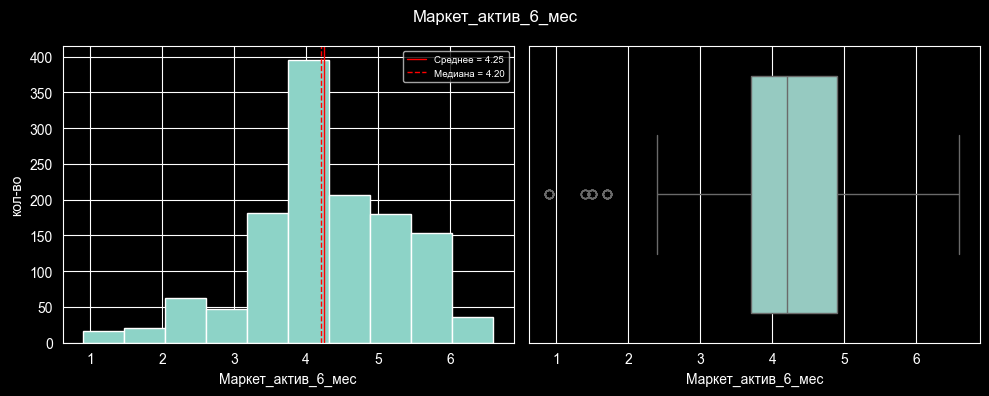

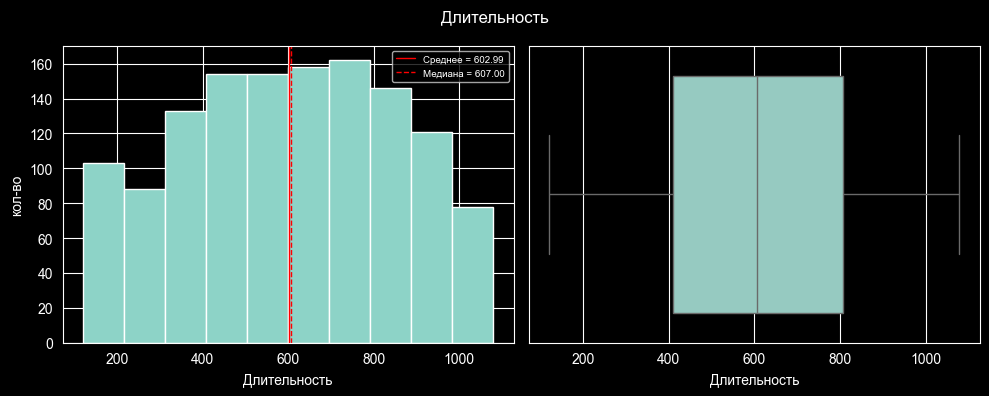

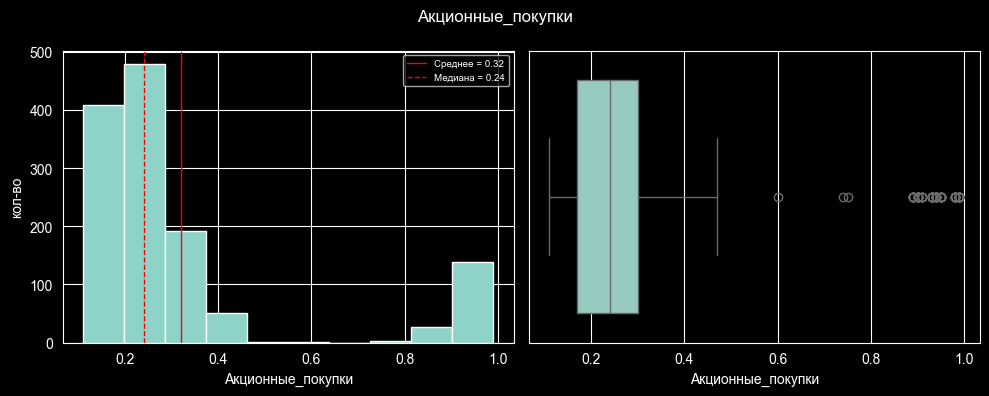

In [25]:
num_columns = ['Маркет_актив_6_мес', 'Длительность', 'Акционные_покупки']

for i in num_columns:
    graph(i, 10, market_file)

- Все данные, кроме Акционных покупок, имеют нормальное распредление. Вероятно, есть сегмент покупателей, которые покупают (стараются покупать) только в момент акции. За выбросы это считать нельзя, т.к. это показывает нам реальное потребителськое поведение. При корреляционном анализе стоит использовать корреляцию Спирмана.

In [26]:
def graph_cat(cat, data):
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    sns.countplot(x=data[cat] ,ax=axs[0])
    axs[0].set_ylabel('кол-во')
    axs[0].set_xlabel('')

    data[cat].value_counts().plot(kind='pie',autopct='%1.0f%%', ax=axs[1])
    axs[1].set_ylabel('')
    fig.suptitle(cat)
    plt.tight_layout()

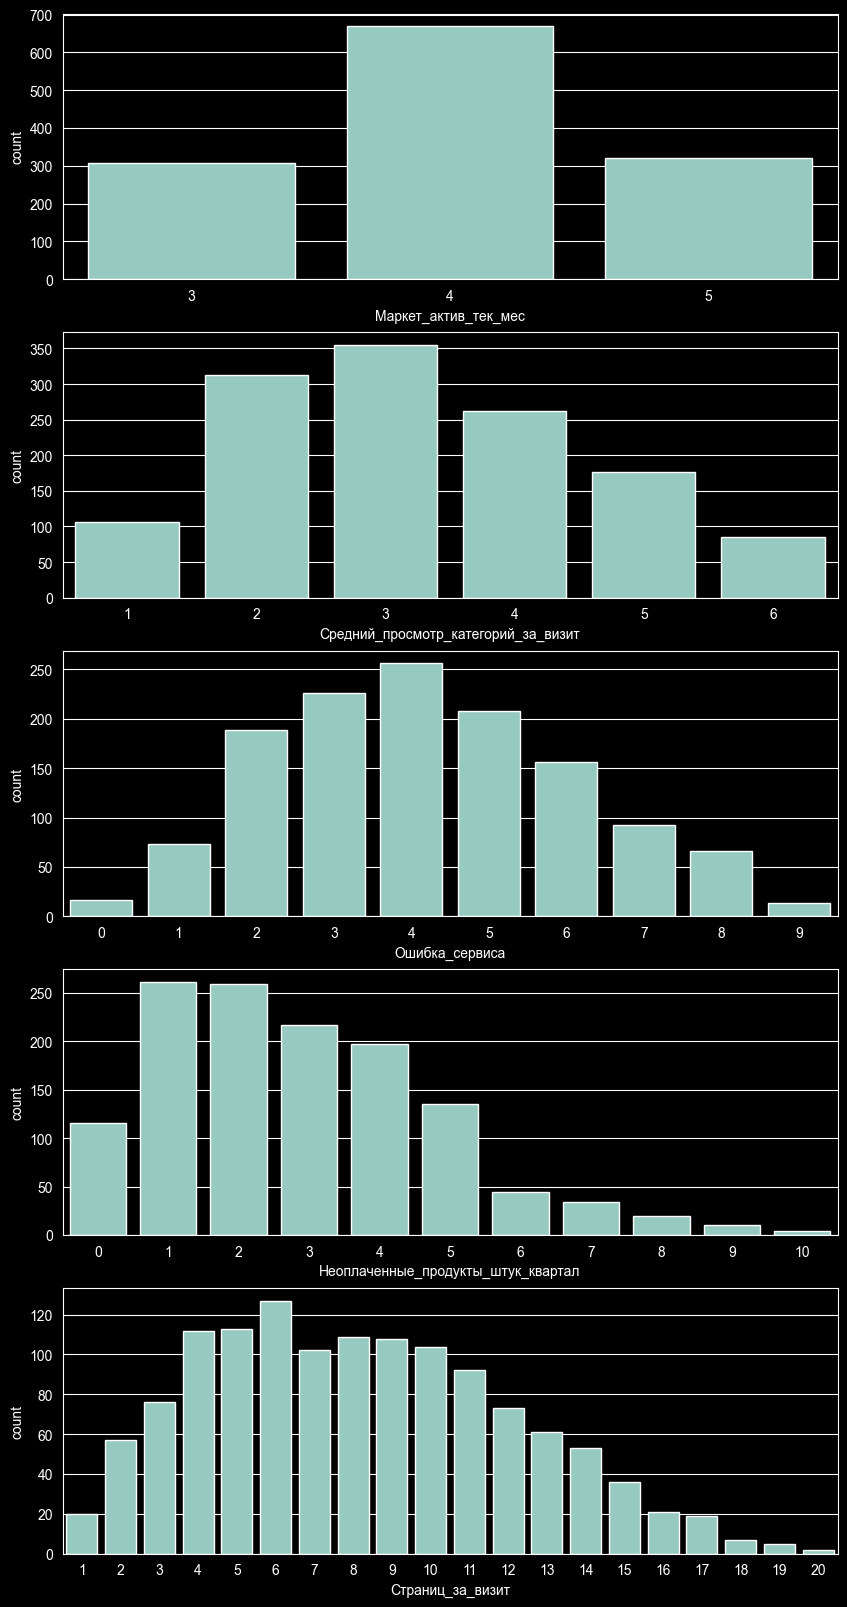

In [27]:
fig, axs = plt.subplots(5, 1, figsize=(10, 20))
j=0
for i in cat_list:
    sns.countplot(x=market_file[i], ax=axs[j])
    j+=1

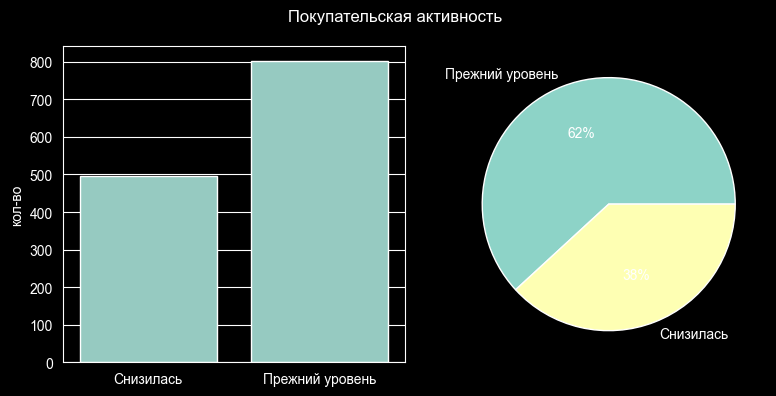

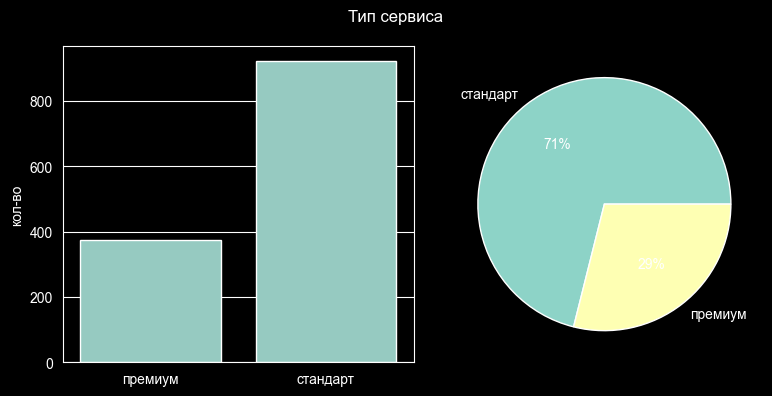

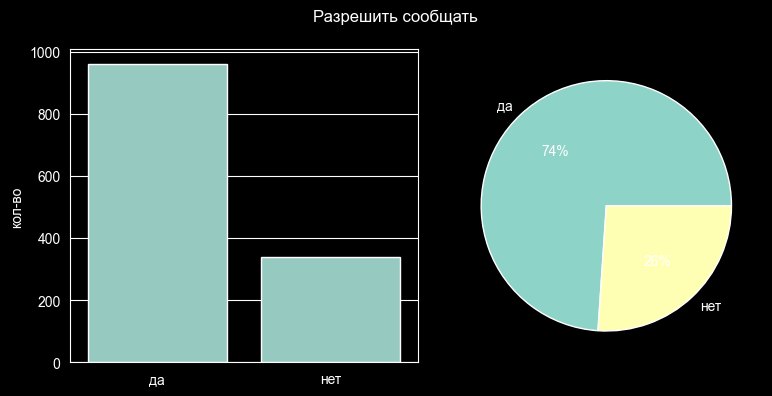

In [28]:
for i in cat_col_mf:
    if i == 'Популярная_категория':
        pass
    else:
        graph_cat(i, market_file)

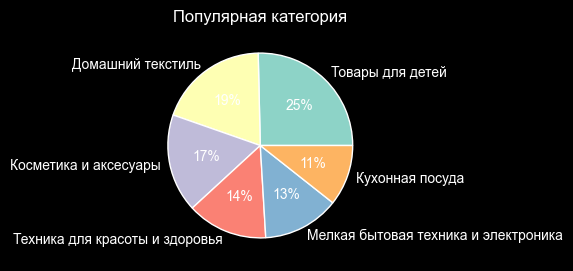

In [29]:
plt.figure(figsize=(5, 3))

market_file['Популярная_категория'].value_counts().plot(
    y = 'count',
    kind = 'pie',
    autopct='%1.0f%%',
    title = 'Популярная категория'
)
plt.ylabel('')
plt.show()

- Самой популярной категорией являются товары для детей (25%)
- Самой непопулярной $-$ кухонная посуда (11%)

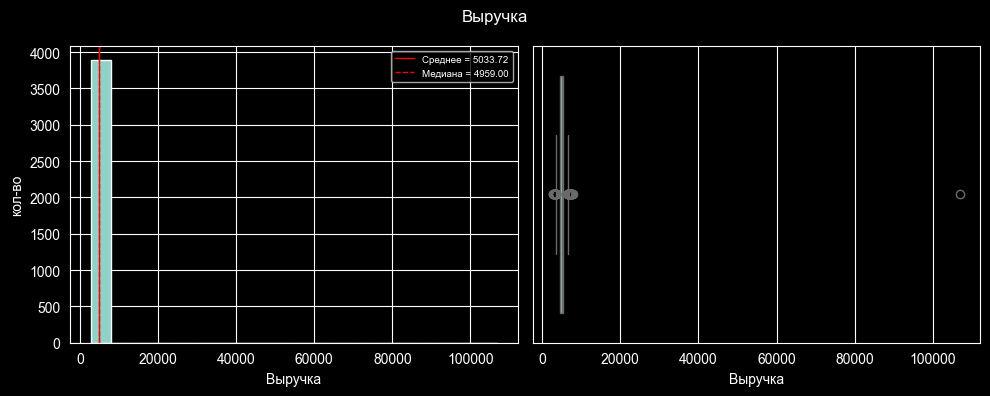

In [30]:
graph('Выручка', 20, market_money)

На лицо явный выброс, стоит удалить его.

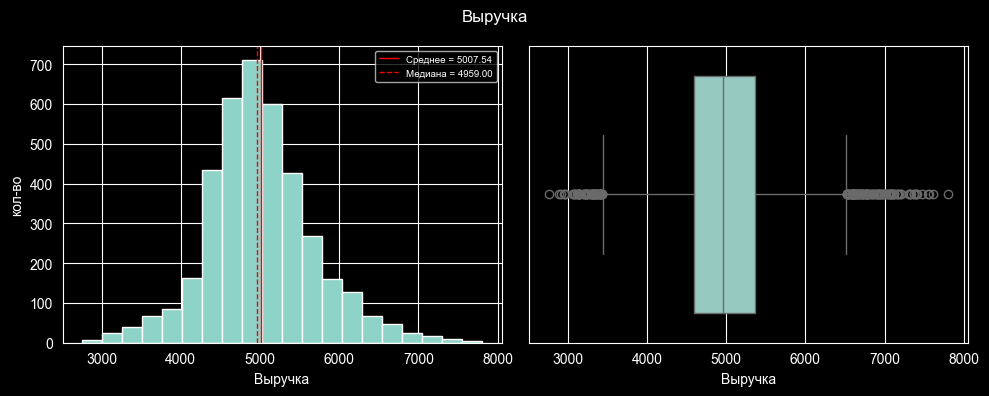

In [31]:
market_money = market_money[market_money['Выручка']<40000]
graph('Выручка', 20, market_money)

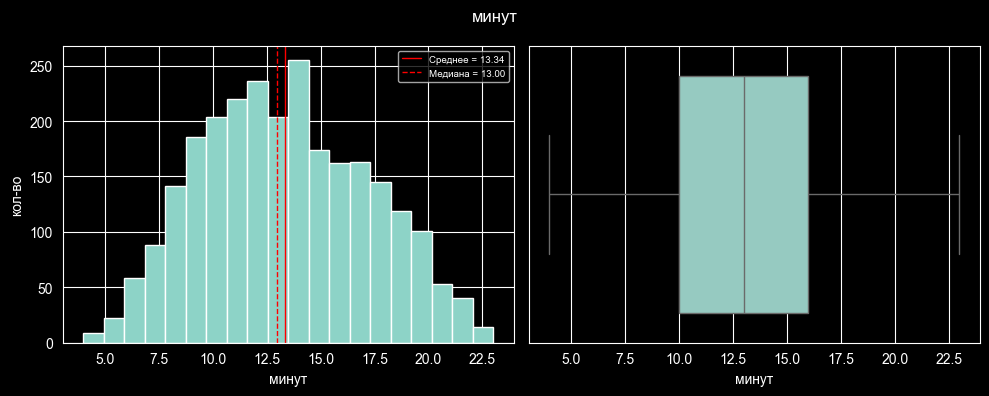

In [32]:
graph('минут', 20, market_time)

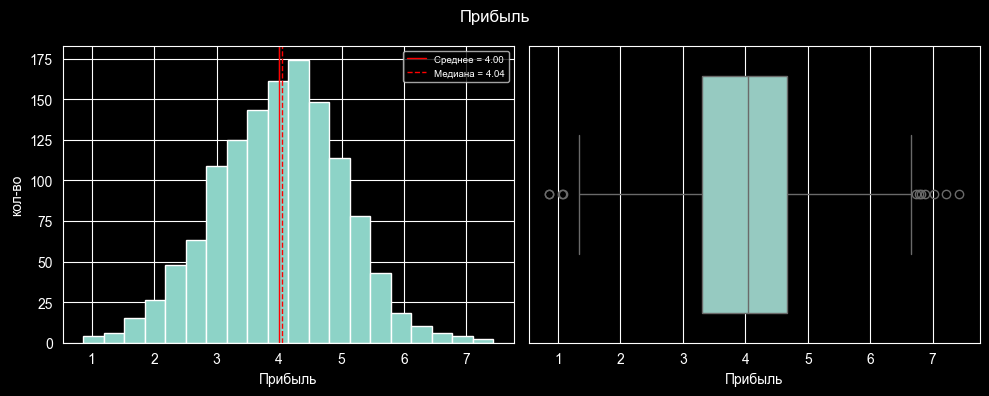

In [33]:
graph('Прибыль', 20, money)

## Вывод:
- Отфильтровали клиентов. Оставили тех, кто покупал в течение 3 месяцев
- Провели исследовательский анализ данных колличественных и категориальных признаков.
- Удалили выброс в market_money
- Приняли решение, что распределение Акционные_покупки ненормальное
- Скорее всего есть клиенты, котрые стараются покупать только во время акций
- Все остальные распредления нормальные
- Более 70% клиентов подписаны на рассылку
- 62% клиентов сохранили свою активность
- 71% клиентов пользуется стандартным сервисом
- На одного покупателя в среднем приходятся 4 ошибки на сайте
- В среднем 8 страниц смотрит покупатель за один визит
- В среднем происходит 4 маркетинговых коммуникаций с клиентом
- В среднем клиент проводит на сайте 12 минут
- Самая популярная категория $-$ Товары для детей (25%)
- Самая непопулярная категория $-$ Кухонная посуда (11%)

## 4. Объединение таблиц

In [34]:
transform_market_money = market_money.pivot_table(index='id', columns='Период', values='Выручка', aggfunc='first').reset_index()
transform_market_money.columns.name = None
transform_market_money.head()

,id,предыдущий_месяц,препредыдущий_месяц,текущий_месяц
0,215349,5216.0,4472.0,4971.6
1,215350,5457.5,4826.0,5058.4
2,215351,6158.0,4793.0,6610.4
3,215352,5807.5,4594.0,5872.5
4,215353,4738.5,5124.0,5388.5


In [35]:
transform_market_time = market_time.pivot_table(index='id', columns='Период', values='минут', aggfunc='first').reset_index()
transform_market_time.columns.name = None
transform_market_time.head()

,id,предыдущий_месяц,текущий_месяц
0,215349,12,10
1,215350,8,13
2,215351,11,13
3,215352,8,11
4,215353,10,10


In [36]:
df = pd.merge(transform_market_money, transform_market_time, on='id')
df.columns = ['id', 'выручка_предыдущий_месяц', 'выручка_препредыдущий_месяц', 'выручка_текущий_месяц',
       'минут_предыдущий_месяц', 'минут_текущий_месяц']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1297 entries, 0 to 1296
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           1297 non-null   int64  
 1   выручка_предыдущий_месяц     1297 non-null   float64
 2   выручка_препредыдущий_месяц  1297 non-null   float64
 3   выручка_текущий_месяц        1296 non-null   float64
 4   минут_предыдущий_месяц       1297 non-null   int64  
 5   минут_текущий_месяц          1297 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 60.9 KB


In [37]:
df = pd.merge(market_file, df, on='id')
df = df.dropna()
df.set_index('id', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296 entries, 215349 to 216647
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Покупательская активность            1296 non-null   object 
 1   Тип сервиса                          1296 non-null   object 
 2   Разрешить сообщать                   1296 non-null   object 
 3   Маркет_актив_6_мес                   1296 non-null   float64
 4   Маркет_актив_тек_мес                 1296 non-null   int64  
 5   Длительность                         1296 non-null   int64  
 6   Акционные_покупки                    1296 non-null   float64
 7   Популярная_категория                 1296 non-null   object 
 8   Средний_просмотр_категорий_за_визит  1296 non-null   int64  
 9   Неоплаченные_продукты_штук_квартал   1296 non-null   int64  
 10  Ошибка_сервиса                       1296 non-null   int64  
 11  Страниц_за_визит            

## 5. Корреляционный анализ

In [38]:
df.head()

,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
id,,,,,,,,,,,,,,,,,
215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11
215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10


In [39]:
num_columns = ['Маркет_актив_6_мес','Длительность',
               'Акционные_покупки', 'выручка_предыдущий_месяц',
               'выручка_текущий_месяц','минут_предыдущий_месяц',
               'минут_текущий_месяц']

In [40]:
matrix = (df.phik_matrix(interval_cols=num_columns))
matrix

,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
Покупательская активность,1.000000,0.129940,0.000000,0.544831,0.000000,0.099901,0.506276,0.299717,0.539607,0.405041,0.224154,0.747331,0.224638,0.429283,0.197213,0.685138,0.576770
Тип сервиса,0.129940,1.000000,0.289965,0.089911,0.045258,0.401411,0.030010,0.070809,0.185391,0.113015,0.079515,0.087776,0.000000,0.323045,0.124216,0.131814,0.000000
Разрешить сообщать,0.000000,0.289965,1.000000,0.000000,0.052618,0.253831,0.012198,0.073684,0.070359,0.162524,0.021839,0.097094,0.080842,0.316196,0.060907,0.038387,0.000000
Маркет_актив_6_мес,0.544831,0.089911,0.000000,1.000000,0.079854,0.000000,0.279553,0.150386,0.206788,0.217731,0.142401,0.376035,0.155476,0.562946,0.039795,0.363950,0.330601
Маркет_актив_тек_мес,0.000000,0.045258,0.052618,0.079854,1.000000,0.174233,0.000000,0.136243,0.246633,0.142887,0.116946,0.000000,0.051824,0.320357,0.000000,0.107945,0.061410
Длительность,0.099901,0.401411,0.253831,0.000000,0.174233,1.000000,0.000000,0.000000,0.186795,0.128222,0.175608,0.128089,0.125572,0.419332,0.147048,0.026448,0.101481
Акционные_покупки,0.506276,0.030010,0.012198,0.279553,0.000000,0.000000,1.000000,0.122385,0.199180,0.246665,0.000000,0.350714,0.060733,0.611785,0.071094,0.262324,0.250558
Популярная_категория,0.299717,0.070809,0.073684,0.150386,0.136243,0.000000,0.122385,1.000000,0.226116,0.254746,0.000000,0.177637,0.252097,0.242388,0.237240,0.195233,0.089883
Средний_просмотр_категорий_за_визит,0.539607,0.185391,0.070359,0.206788,0.246633,0.186795,0.199180,0.226116,1.000000,0.334927,0.070315,0.293781,0.098440,0.000000,0.092597,0.159837,0.182568
Неоплаченные_продукты_штук_квартал,0.405041,0.113015,0.162524,0.217731,0.142887,0.128222,0.246665,0.254746,0.334927,1.000000,0.000000,0.310843,0.193536,0.612363,0.166017,0.197933,0.168998


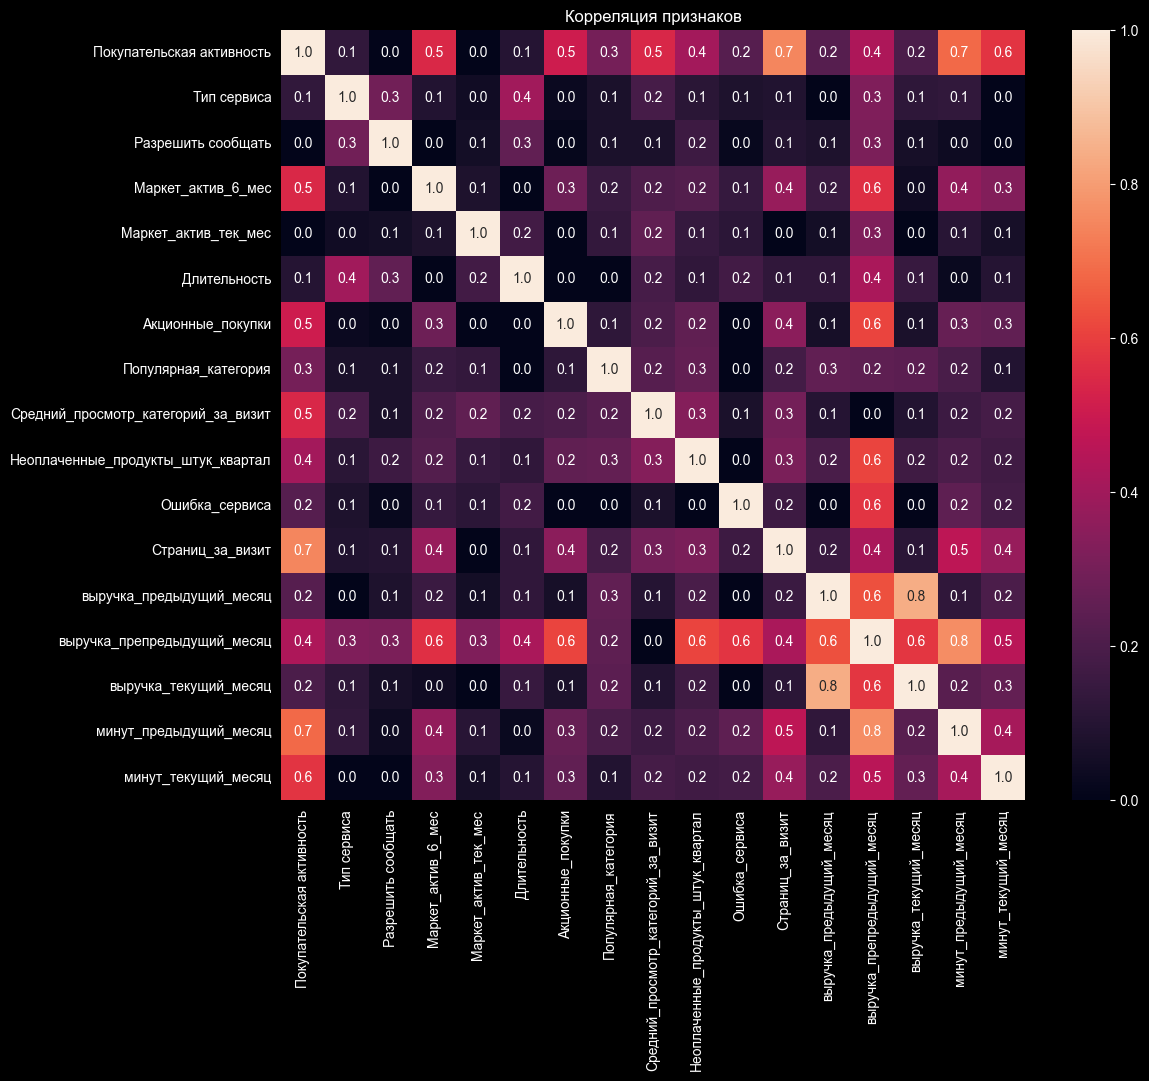

In [41]:
plt.figure(figsize=(12, 10))
sns.heatmap(matrix, annot=True, fmt=".1f")
plt.title('Корреляция признаков')
plt.show()

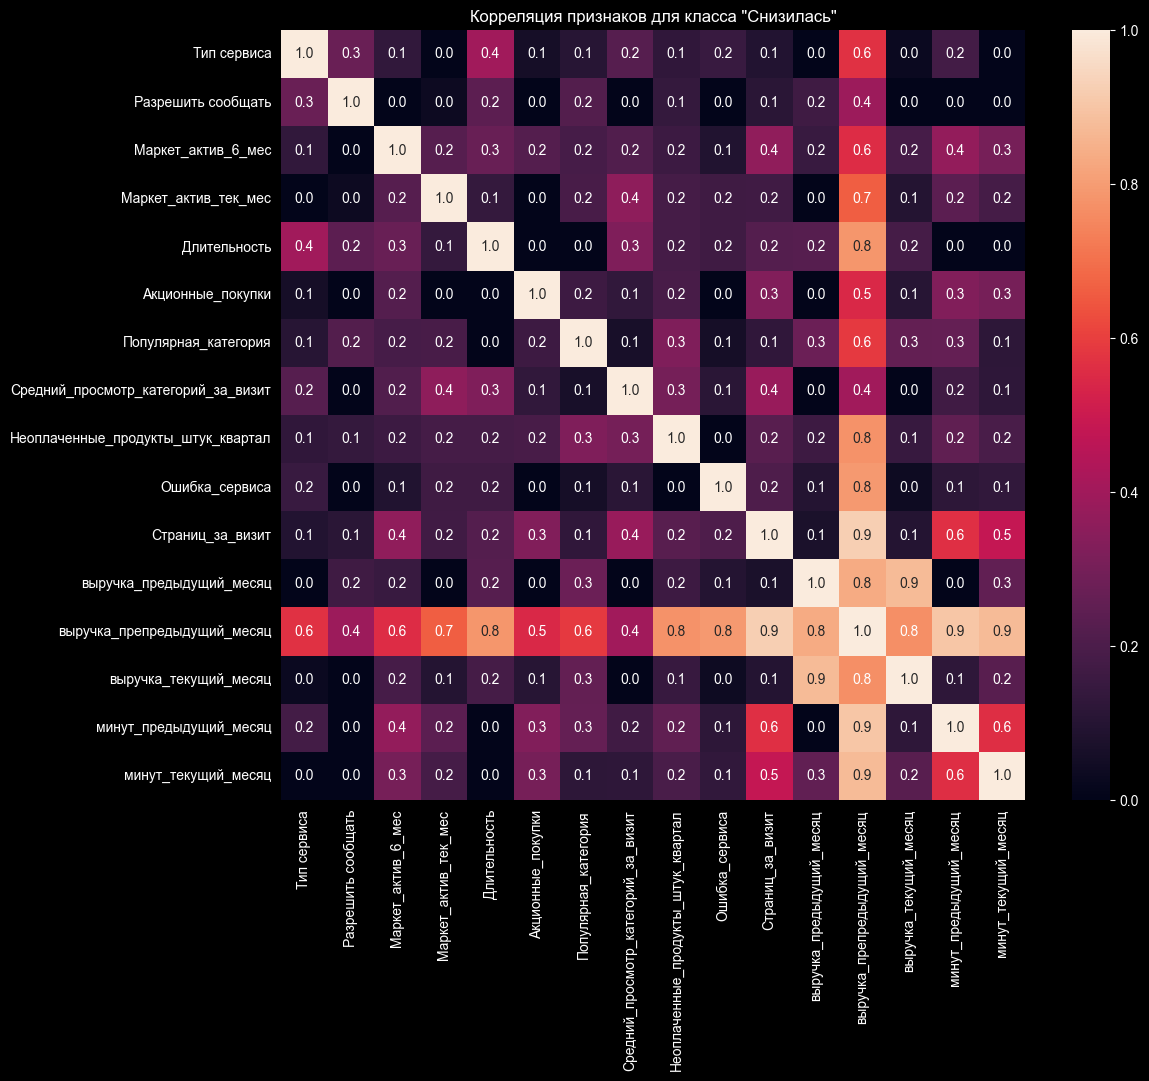

In [42]:
df_reduce = df[df['Покупательская активность'] == "Снизилась"].drop('Покупательская активность', axis=1)
matrix_reduce = df_reduce[df_reduce.columns.to_list()].phik_matrix(interval_cols=num_columns)

plt.figure(figsize=(12, 10))
sns.heatmap(matrix_reduce, annot=True, fmt=".1f")
plt.title('Корреляция признаков для класса "Снизилась"')
plt.show()

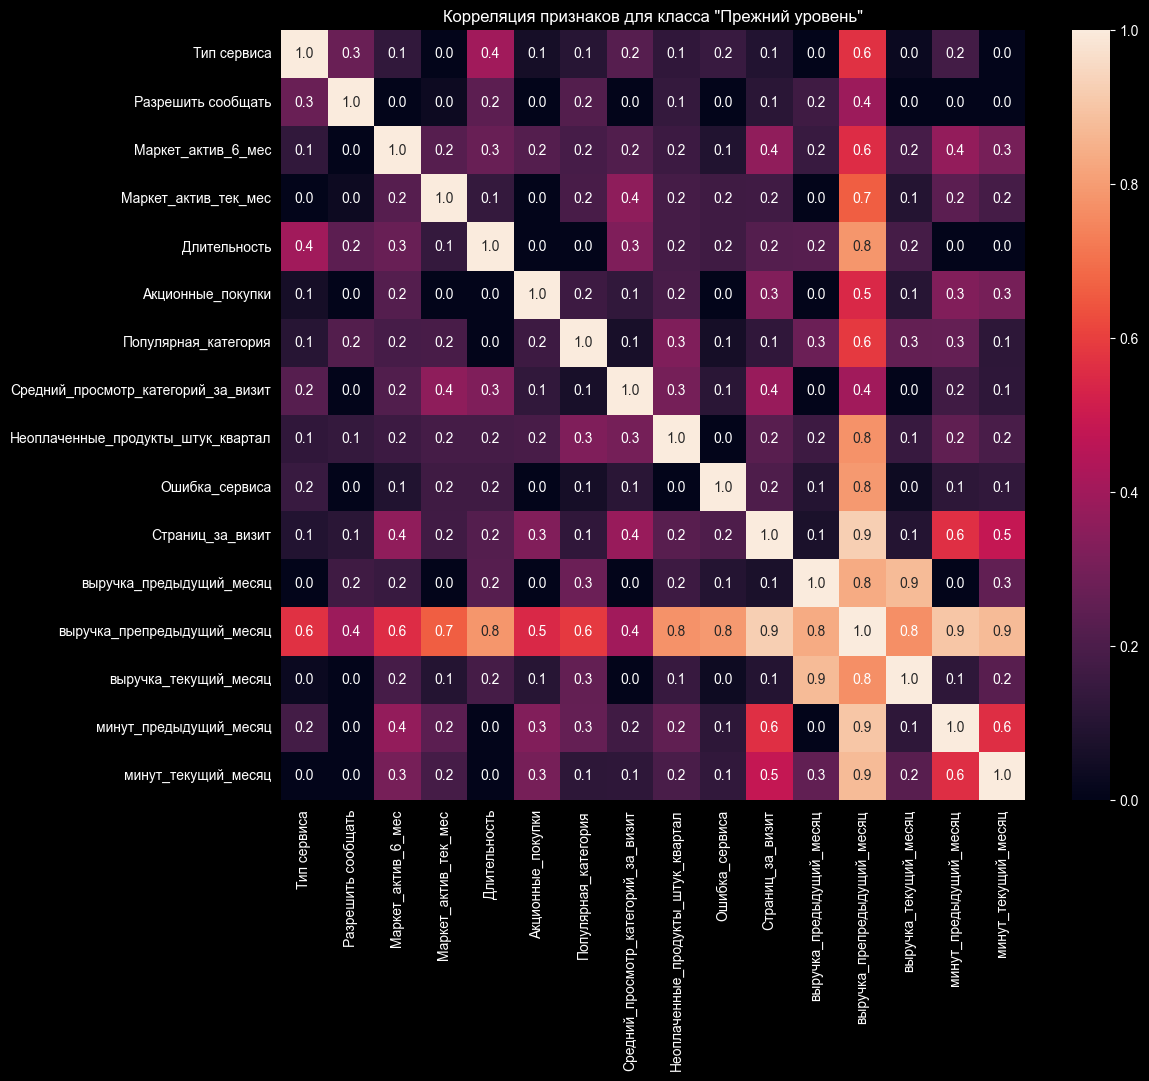

In [43]:
df_stat = df[df['Покупательская активность'] == "Прежний уровень"].drop('Покупательская активность', axis=1)
matrix_stat = df_stat[df_stat.columns.to_list()].phik_matrix(interval_cols=num_columns)

plt.figure(figsize=(12, 10))
sns.heatmap(matrix_reduce, annot=True, fmt=".1f")
plt.title('Корреляция признаков для класса "Прежний уровень"')
plt.show()

Мультиколлинеарности не наблюдается, однако стоит обратить внимания на связь выручки за текущий и предыдущий месяцы

# 6. Использование пайплайнов

В качестве метрики я возьму ROC-AUC. Она более устойчива к выбросам, дает наиболее обобщенную оценку(не зависит от порога).

In [44]:
ohe_columns = ['Разрешить сообщать', 'Популярная_категория']
ord_columns = ['Тип сервиса']
num_columns = ['Маркет_актив_6_мес', 'Маркет_актив_тек_мес',
               'Длительность', 'Акционные_покупки',
               'Средний_просмотр_категорий_за_визит','Неоплаченные_продукты_штук_квартал',
               'Ошибка_сервиса', 'Страниц_за_визит',
               'выручка_препредыдущий_месяц','выручка_предыдущий_месяц',
               'выручка_текущий_месяц',
               'минут_предыдущий_месяц', 'минут_текущий_месяц']
RANDOM_STATE = 42

y = df['Покупательская активность']
X = df.drop(['Покупательская активность'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(
        X, 
        y, 
        random_state=RANDOM_STATE,
        stratify=y
)

In [45]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)


In [46]:
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore')
        )
    ]
)

In [47]:
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',  
            OrdinalEncoder(
                categories=[
                    ['стандарт', 'премиум']
                ], 
                handle_unknown='use_encoded_value',
                unknown_value=-np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

In [48]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [49]:
pipe_final= Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', KNeighborsClassifier( n_neighbors=17))
])

In [50]:
param_grid = [
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(1, 20),
        'models__weights': ['uniform', 'distance'],
        'models__p': [1, 2],
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]   
    },
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 11),
        'models__max_features': range(2, 11),
        'models__criterion': ['gini', 'entropy'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [SVC(random_state=RANDOM_STATE, probability= True)],
        'models__C': range(1, 10),
        'models__kernel': ['rbf', 'linear', 'sigmoid'],
        'models__gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'models__degree': [2, 3, 4],  # для полиномиального ядра
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  

    },
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE)],
        'models__C': range(1, 10),
        'models__penalty': ['l1', 'l2'],
        'models__solver': ['liblinear', 'saga'],  # для l1 и l2
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
] 

In [51]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    scoring='roc_auc', 
    n_jobs=-1,
    random_state=RANDOM_STATE
)
randomized_search.fit(X_train, y_train) 

RandomizedSearchCV(estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore'))]),
                                                                               ['Разрешить '
                                                                                'сообщать',
                                                                                'Популярная_категория']),
                                                                              ('ord',
                                                                               Pipeline(steps=[('simpleImputer...
                                         'models__kernel': ['rbf', 'linear',
                                                            'sigmoid'],
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               'passthrough']},
                                        {'models': [LogisticRegression(random_state=42)],
                                         'models__C': range(1, 10),
                                         'models__penalty': ['l1', 'l2'],
                                         'models__solver': ['liblinear',
                                                            'saga'],
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               'passthrough']}],
                   random_state=42, scoring='roc_auc')

In [52]:
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Разрешить сообщать',
                                                   'Популярная_категория']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                        

In [53]:
print ('Метрика лучшей модели на тренировочной выборке:', randomized_search.best_score_)

Метрика лучшей модели на тренировочной выборке: 0.8976997840816022


In [54]:
pred = randomized_search.predict_proba(X_test)
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, pred[:, 1]):.5f}')

Метрика ROC-AUC на тестовой выборке: 0.91647


## Вывод:
- Лучшая модель: KNeighborsClassifier(n_neighbors=17), MinMaxScaler()
- Метрика roc_auc_score на кросс-валидации - 0.86, на тестовой выборке - 0.90. Это среднее качество модели при разных порогах вероятности.

# 7. Анализ важности признаков

In [55]:
pipe_final.fit(X_train, y_train)
model =  KNeighborsClassifier(n_neighbors=17)

transformed_features = data_preprocessor.get_feature_names_out()
X_train_shap = pipe_final.named_steps['preprocessor'].fit_transform(X_train)
X_train_shap = pd.DataFrame(X_train_shap, columns=transformed_features)

X_test_shap = pipe_final.named_steps['preprocessor'].fit_transform(X_test)
X_test_shap = pd.DataFrame(X_test_shap, columns=transformed_features)

model.fit(X_train_shap, y_train)

KNeighborsClassifier(n_neighbors=17)

In [56]:
label_encoder.transform(['Снизилась', 'Прежний уровень'])

array([1, 0])

  0%|          | 0/50 [00:00<?, ?it/s]

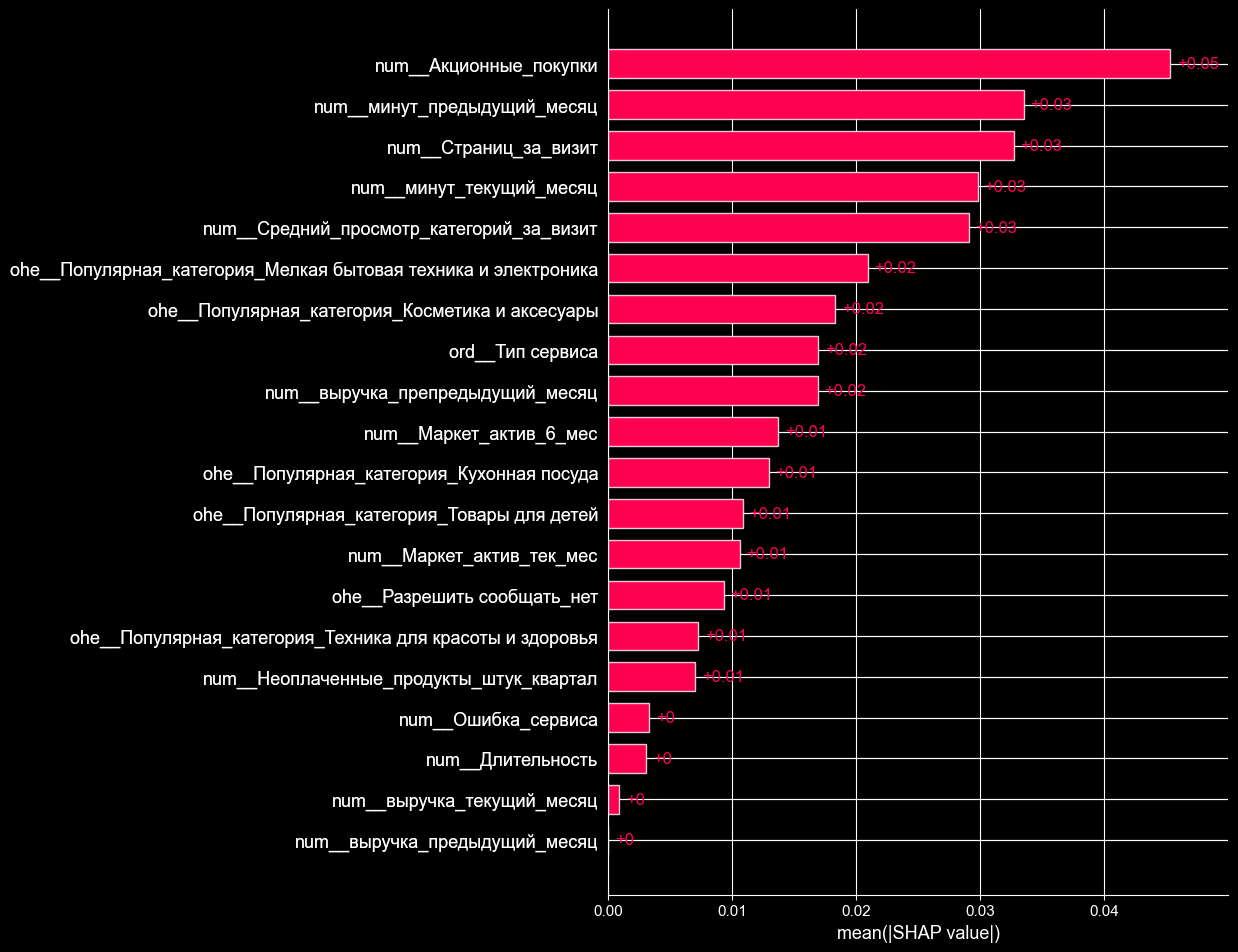

In [57]:
explainer = shap.KernelExplainer(model.predict_proba, X_test_shap[:50])
shap_values = explainer(X_test_shap[:50])

shap.plots.bar(shap_values[:,:,1], max_display=20)

Наиболее значимые признаки:
- Акционные покупки
- Время, проведённое на сайте за предыдущий месяц
- Средний просмотр категорий за визит сайта
  
Наименее значимые:
- Выручка за предыдущий и текущий месяцы
- Популярные категории (без бытовой техники и товаров для красоты)
- Ошибка сервиса

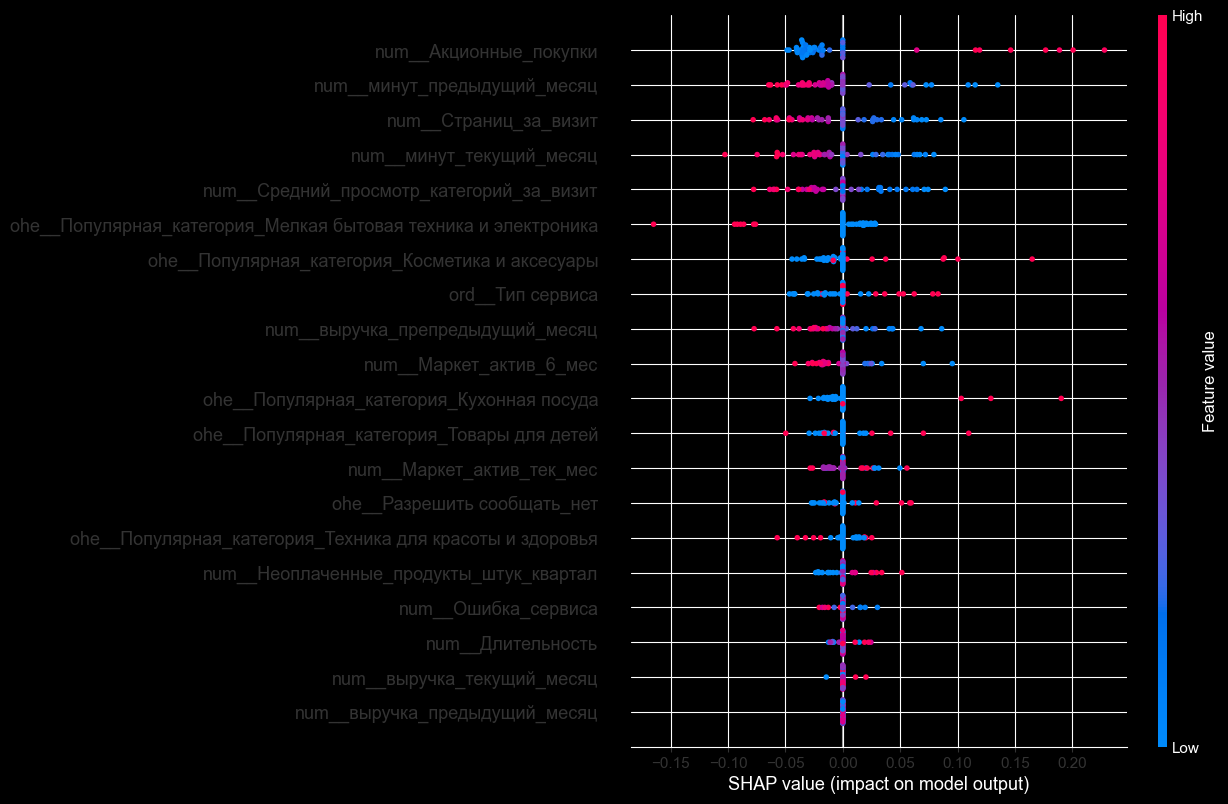

In [58]:
shap.plots.beeswarm(shap_values[:,:,1], max_display = 20)

- "Чем больше доля товаров, купленных во время акций, тем вероятнее, что снизиться покупательская активность" - скорее всего, это связано с тем, что компания проводит мало акций. Возможно следует устраивать больше акций, для сохранения спроса.
- Логично объясняется средний прсомотр за визит. Чем больше категорий клиент просмотрит - тем больше потратит времени - тем вероятнее захочет что-то купить.
- Видимо клиенты недовольны премиум сервисом. Стоит добавить больше "плюшек".

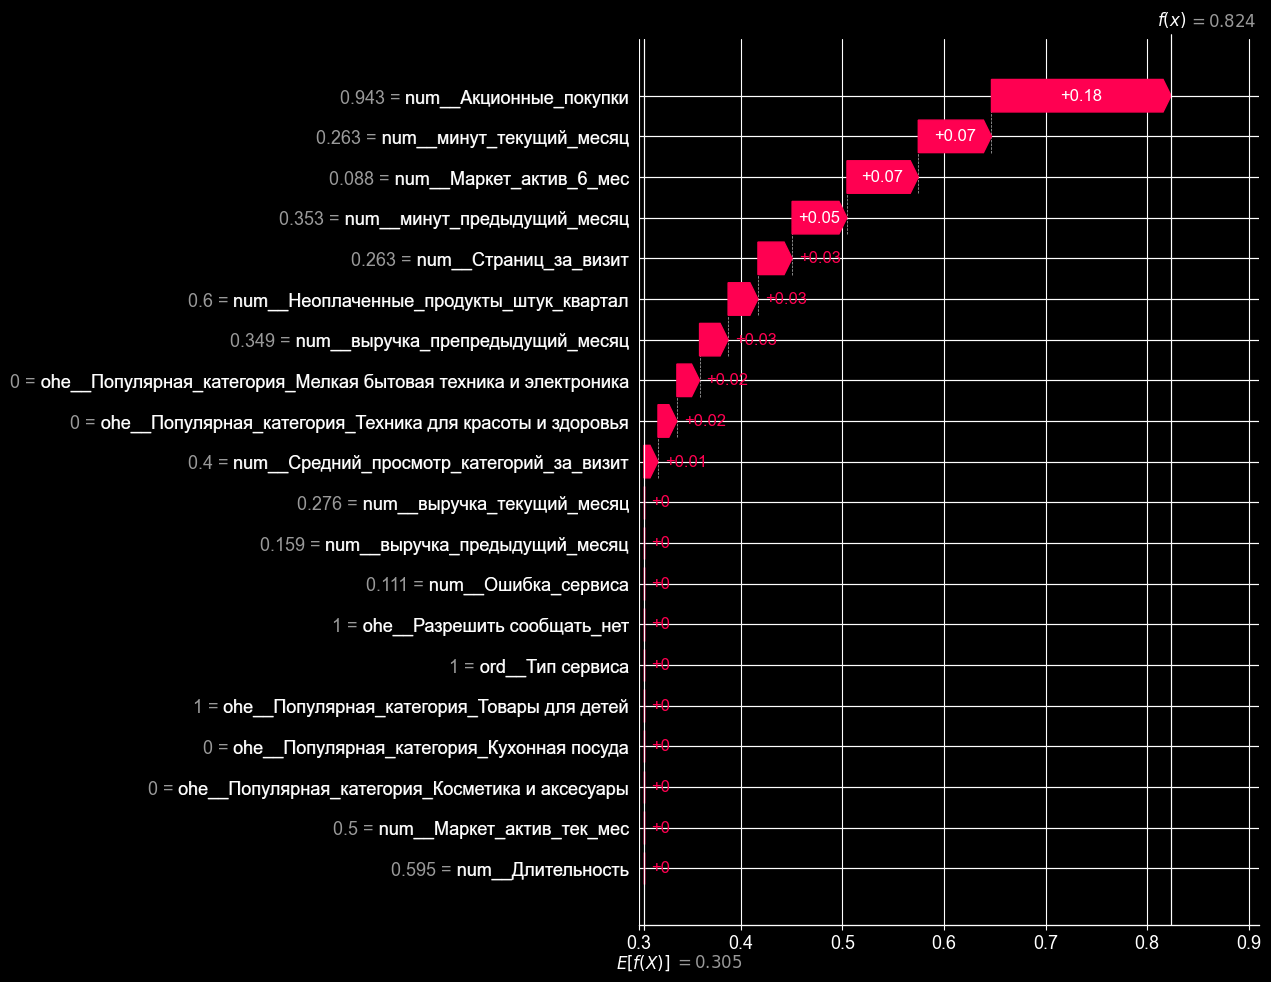

In [59]:
shap.plots.waterfall(shap_values[1,:,1], max_display = 20)

## Вывод:
Наиболее значимые признаки:
- Акционные покупки
- Время, проведённое на сайте за предыдущий месяц
- Средний просмотр категорий за визит сайта
  
Наименее значимые:
- Выручка за предыдущий и текущий месяцы
- Популярные категории (без бытовой техники и товаров для красоты)
- Ошибка сервиса
---
- "Чем больше доля товаров, купленных во время акций, тем вероятнее, что снизиться покупательская активность" - скорее всего, это связано с тем, что компания проводит мало акций. Возможно следует устраивать больше акций, для сохранения спроса.
- Логично объясняется средний прсомотр за визит. Чем больше категорий клиент просмотрит - тем больше потратит времени - тем вероятнее захочет что-то купить. Возможно, следует изучить потребителськое поведение и сделать персонализированные предложения.
- Видимо клиенты недовольны премиум сервисом. Стоит добавить больше "плюшек".

# 8. Сегментация покупателей

Рассмотрим клиентов, которые собираются уйти (вероятность их выбывания более 0.5).

In [60]:
predict = model.predict_proba(X_test_shap)[:, 1]
X_test['predict'] = predict
segment = X_test.merge(money, on = 'id').drop('id', axis=1)
segment.head()

,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,predict,Прибыль
0,стандарт,да,4.1,4,606,0.15,Техника для красоты и здоровья,6,1,4,12,3973.0,4912.0,3289.2,16,17,0.000000,4.69
1,премиум,нет,1.4,4,684,0.94,Товары для детей,3,6,1,6,3548.0,4656.0,4170.7,11,9,0.823529,2.75
2,премиум,да,3.3,4,488,0.13,Домашний текстиль,4,2,8,10,5444.0,4565.0,6335.8,20,11,0.117647,3.16
3,премиум,да,3.5,3,1057,0.35,Домашний текстиль,4,3,5,6,6604.0,4993.0,6758.7,9,9,0.411765,3.74
4,стандарт,нет,5.5,4,147,0.99,Мелкая бытовая техника и электроника,1,2,3,7,5090.0,4451.0,5773.8,15,18,0.294118,4.40


In [61]:
segment = segment[(segment['predict'] >= 0.5)]

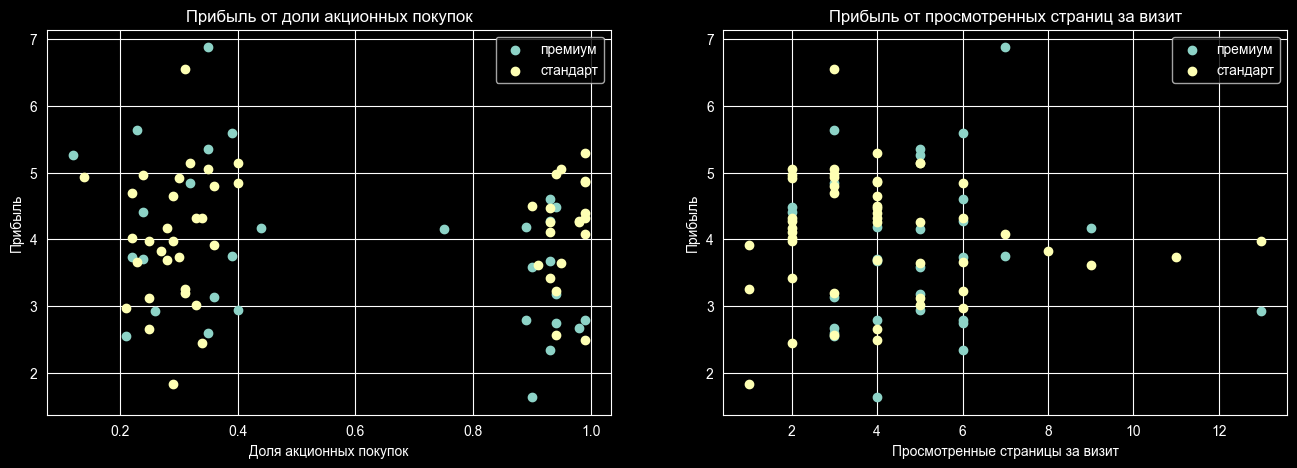

In [62]:
fig, axs = plt.subplots(1,2,figsize=(16,5) )
for cat in segment['Тип сервиса'].unique():
    dots = segment[segment['Тип сервиса'] == cat]
    axs[0].scatter(dots['Акционные_покупки'], dots['Прибыль'], label=cat)

axs[0].legend()        
axs[0].set_xlabel('Доля акционных покупок')
axs[0].set_ylabel('Прибыль')
axs[0].set_title('Прибыль от доли акционных покупок')

for cat in segment['Тип сервиса'].unique():
    dots = segment[segment['Тип сервиса'] == cat]
    axs[1].scatter(dots['Страниц_за_визит'], dots['Прибыль'], label=cat)
axs[1].legend()        
axs[1].set_xlabel('Просмотренные страницы за визит')
axs[1].set_ylabel('Прибыль')
axs[1].set_title('Прибыль от просмотренных страниц за визит')

plt.show()


- Клиенты премиум класса неохотно пользуются акциями
- Большинство клиентов останавливаются на просмотре 4 страниц

# Вывод:
Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений. «В один клик» — современная компания, поэтому её руководство не хочет принимать решения просто так — только на основе анализа данных и бизнес-моделирования. У компании есть небольшой отдел цифровых технологий, и вам предстоит побыть в роли стажёра в этом отделе. Перед нами стояла задача разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.
Данные были проверены на дубликаты и пропуски. На стадии исследовательского анализа данных был удалён один выброс.
Для поиска лучшей модели был написан пайплайн, в котором перебирались способы масштабирования данных, модели и гиперпараметры к ним. По итогу лучшей моделью оказалась - KNeighborsClassifier(n_neighbors=17).
При моделировании и принятии бизнесс-решений:

"Чем больше доля товаров, купленных во время акций, тем вероятнее, что снизиться покупательская активность" - скорее всего, это связано с тем, что компания проводит мало акций. Возможно следует устраивать больше акций, для сохранения спроса.
Логично объясняется средний прсомотр за визит. Чем больше категорий клиент просмотрит - тем больше потратит времени - тем вероятнее захочет что-то купить. Возможно, следует изучить потребителськое поведение и сделать персонализированные предложения.
Видимо клиенты недовольны премиум сервисом. Виден отток клиентов премиум класса. Они очень неохотно принмают акции, стоит обратить внимание именно на них, возможно, следует сделать акции специально для премиум класса. Возможно, стоит добавить другие функции к сервису.

Наиболее популярные категории товаров - "Товары для детей" и "Косметика и аксессуары".
Пользователи, посещающие мало страниц за визит, имеют одни из самых наибольших вероятностей, на снижение своей активности. Необходимо придумать систему рекомендаций товаров.